In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score,
    recall_score, precision_score)
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import lightgbm as lgb
import shap
plt.style.use('dark_background')

##Exploratory Data Analysis

In [2]:
df = pd.read_csv('Customer-Churn-Records.csv')
print(f'Dataset Size: {df.shape[0]:,} rows x {df.shape[1]} columns')
display(df.head())
print('\nMissing Values:')
print(df.isnull().sum())

Dataset Size: 10,000 rows x 18 columns


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425



Missing Values:
RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64


In [3]:
print('Churn Distribution:')
print(df['Exited'].value_counts())
print(f"\nChurn Rate: {df['Exited'].mean()*100:.1f}%")

Churn Distribution:
Exited
0    7962
1    2038
Name: count, dtype: int64

Churn Rate: 20.4%


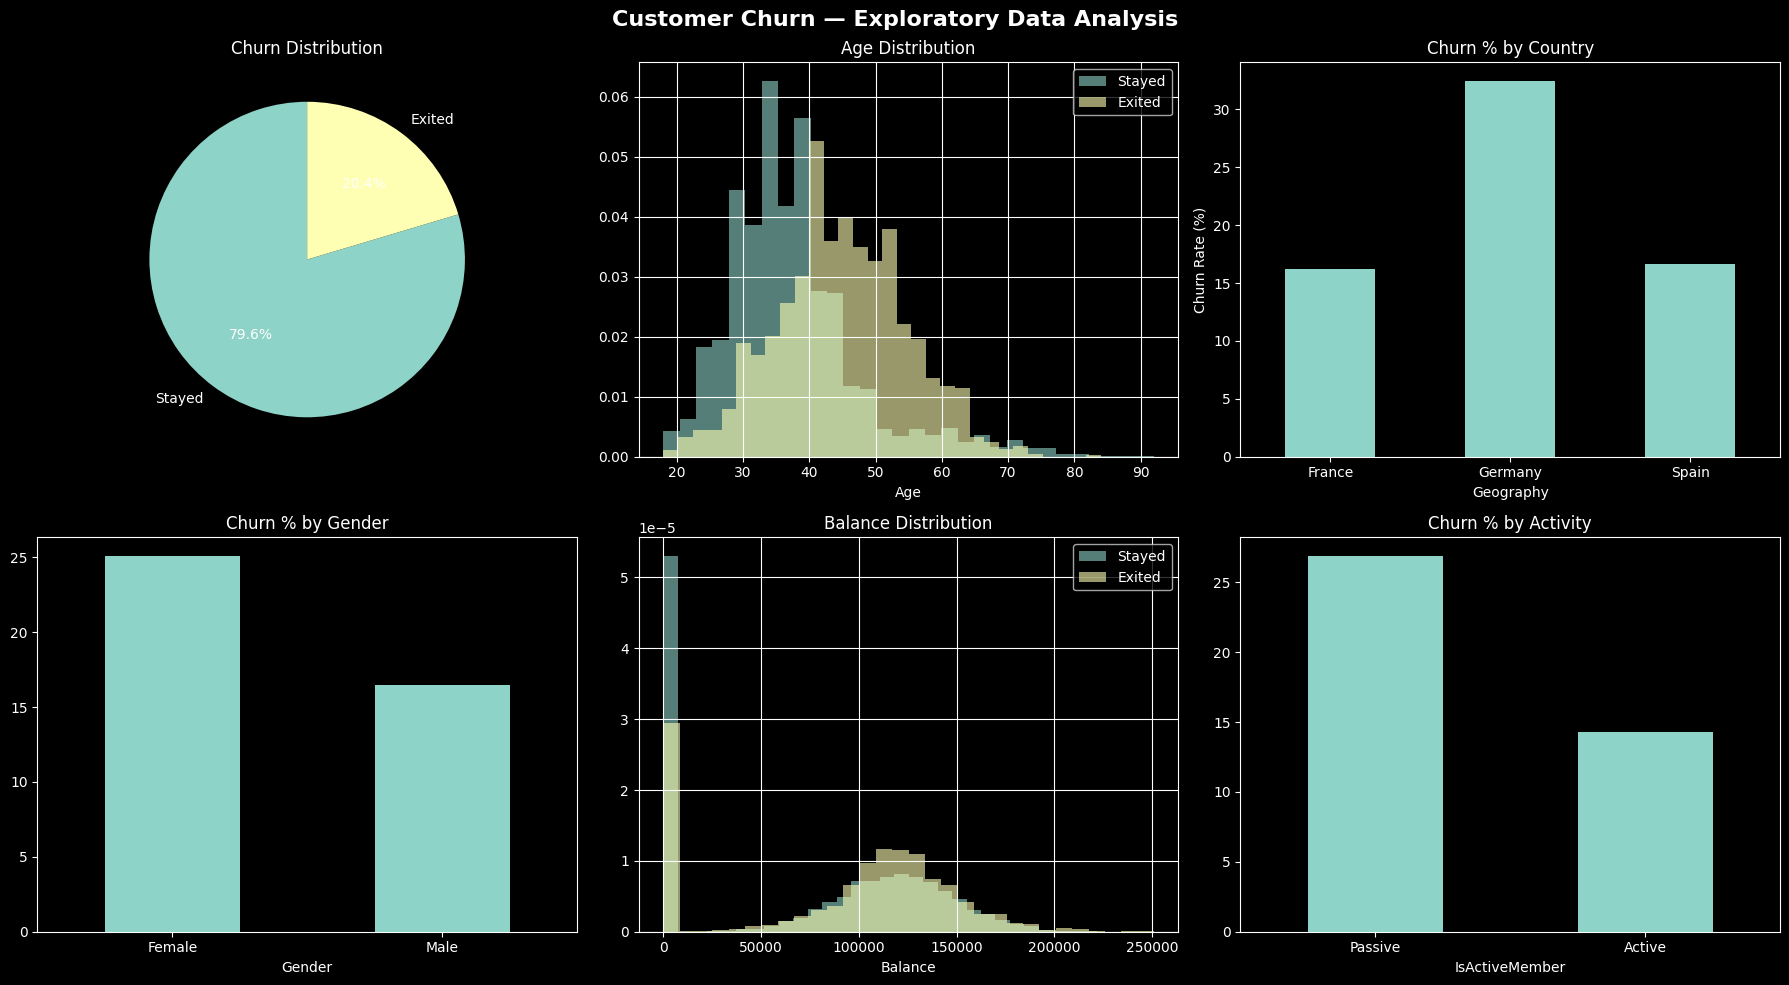

In [ ]:
#plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Customer Churn — Exploratory Data Analysis', fontsize=16, fontweight='bold')

# 1) Churn Distribution
df['Exited'].value_counts().plot(kind='pie', ax=axes[0,0],
    labels=['Stayed', 'Exited'], autopct='%1.1f%%',
    startangle=90)
axes[0,0].set_title('Churn Distribution'); axes[0,0].set_ylabel('')

# 2) Age Distribution
for exited, label in [(0, 'Stayed'), (1, 'Exited')]:
    df[df['Exited']==exited]['Age'].hist(bins=30, alpha=0.6,
                                          density=True, ax=axes[0,1], label=label)
axes[0,1].set_title('Age Distribution'); axes[0,1].legend()
axes[0,1].set_xlabel('Age')

# 3) Country
geo = df.groupby('Geography')['Exited'].mean() * 100
geo.plot(kind='bar', ax=axes[0,2], rot=0)
axes[0,2].set_title('Churn % by Country'); axes[0,2].set_ylabel('Churn Rate (%)')

# 4) Gender
gender = df.groupby('Gender')['Exited'].mean() * 100
gender.plot(kind='bar', ax=axes[1,0], rot=0)
axes[1,0].set_title('Churn % by Gender')

# 5) Balance
for exited, label in [(0, 'Stayed'), (1, 'Exited')]:
    df[df['Exited']==exited]['Balance'].hist(bins=30, alpha=0.6,
                                              density=True, ax=axes[1,1], label=label)
axes[1,1].set_title('Balance Distribution'); axes[1,1].legend(); axes[1,1].set_xlabel('Balance')

# 6) Active Member
active = df.groupby('IsActiveMember')['Exited'].mean() * 100
active.plot(kind='bar', ax=axes[1,2], rot=0)
axes[1,2].set_xticklabels(['Passive', 'Active'])
axes[1,2].set_title('Churn % by Activity')

plt.tight_layout()
plt.show()

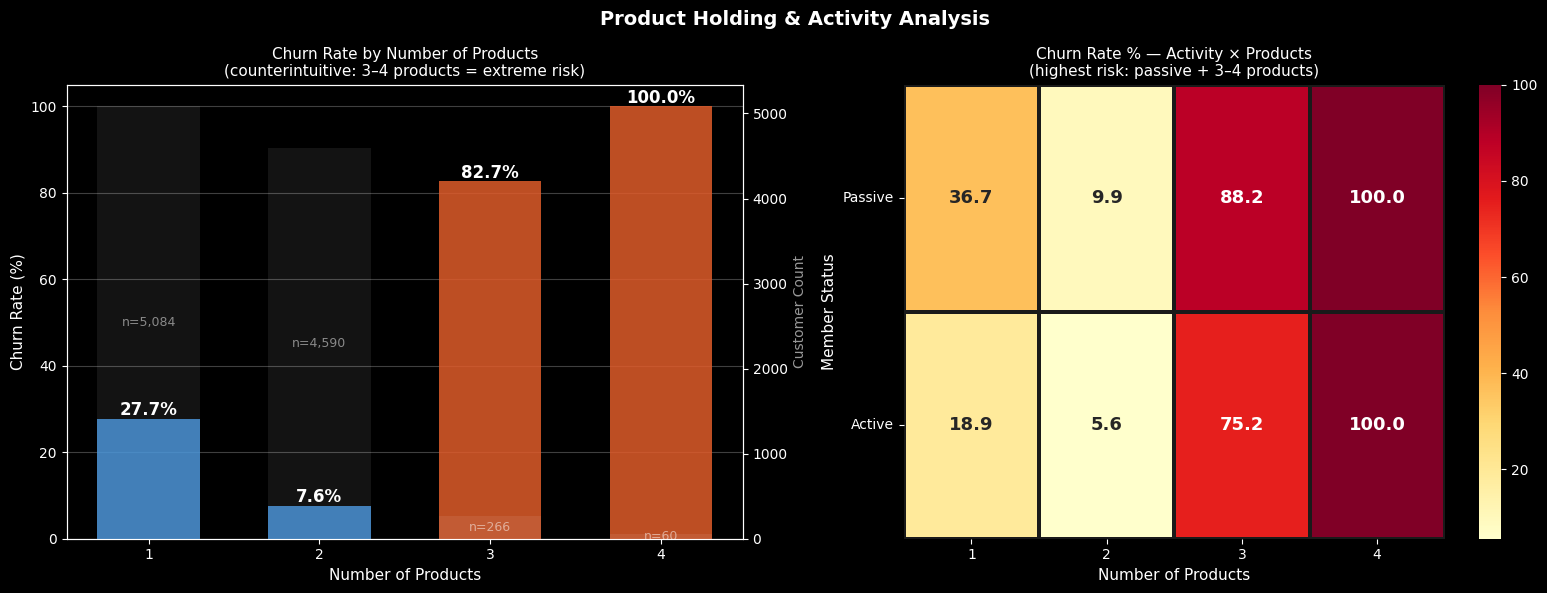

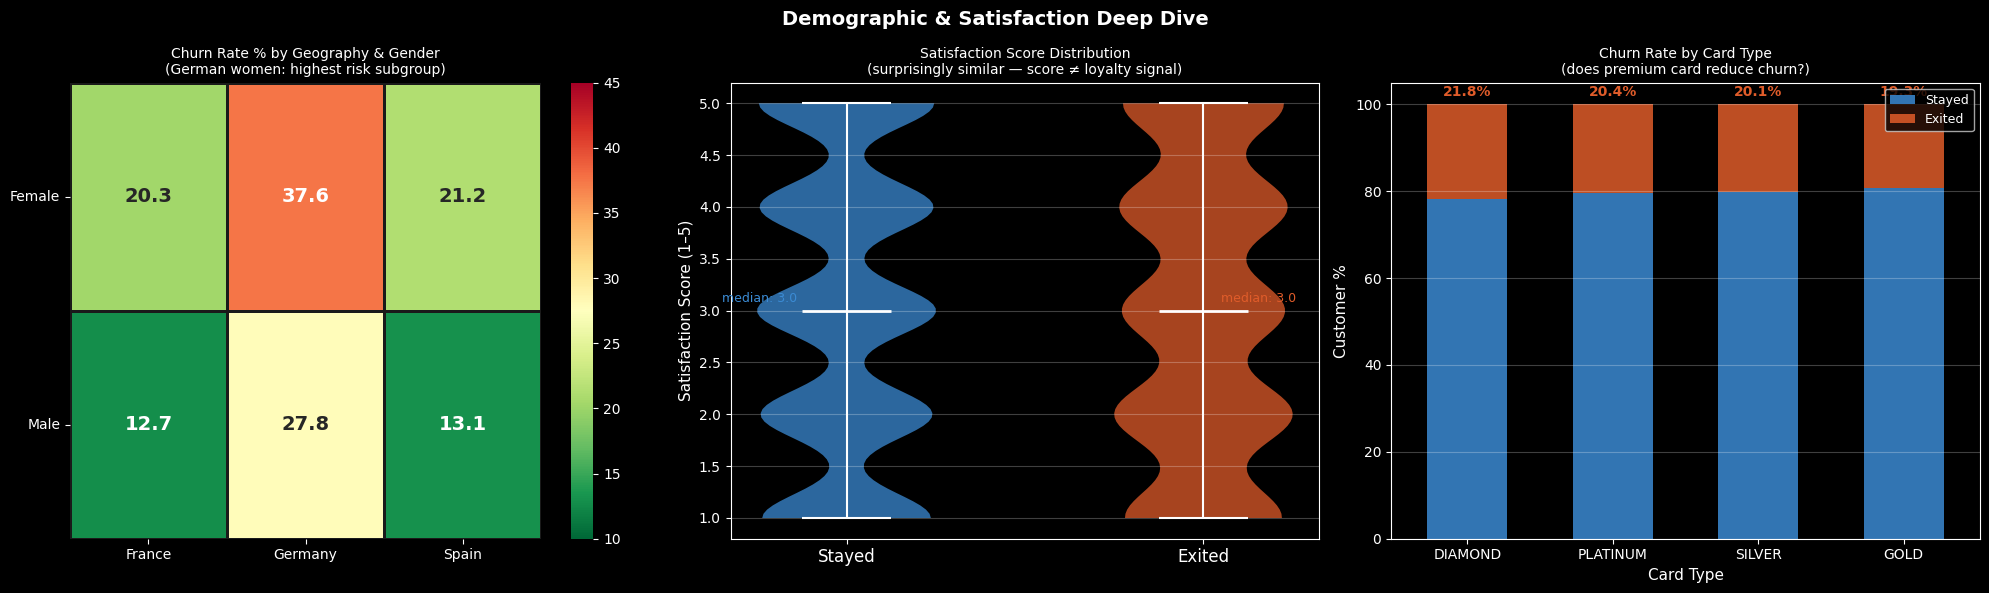

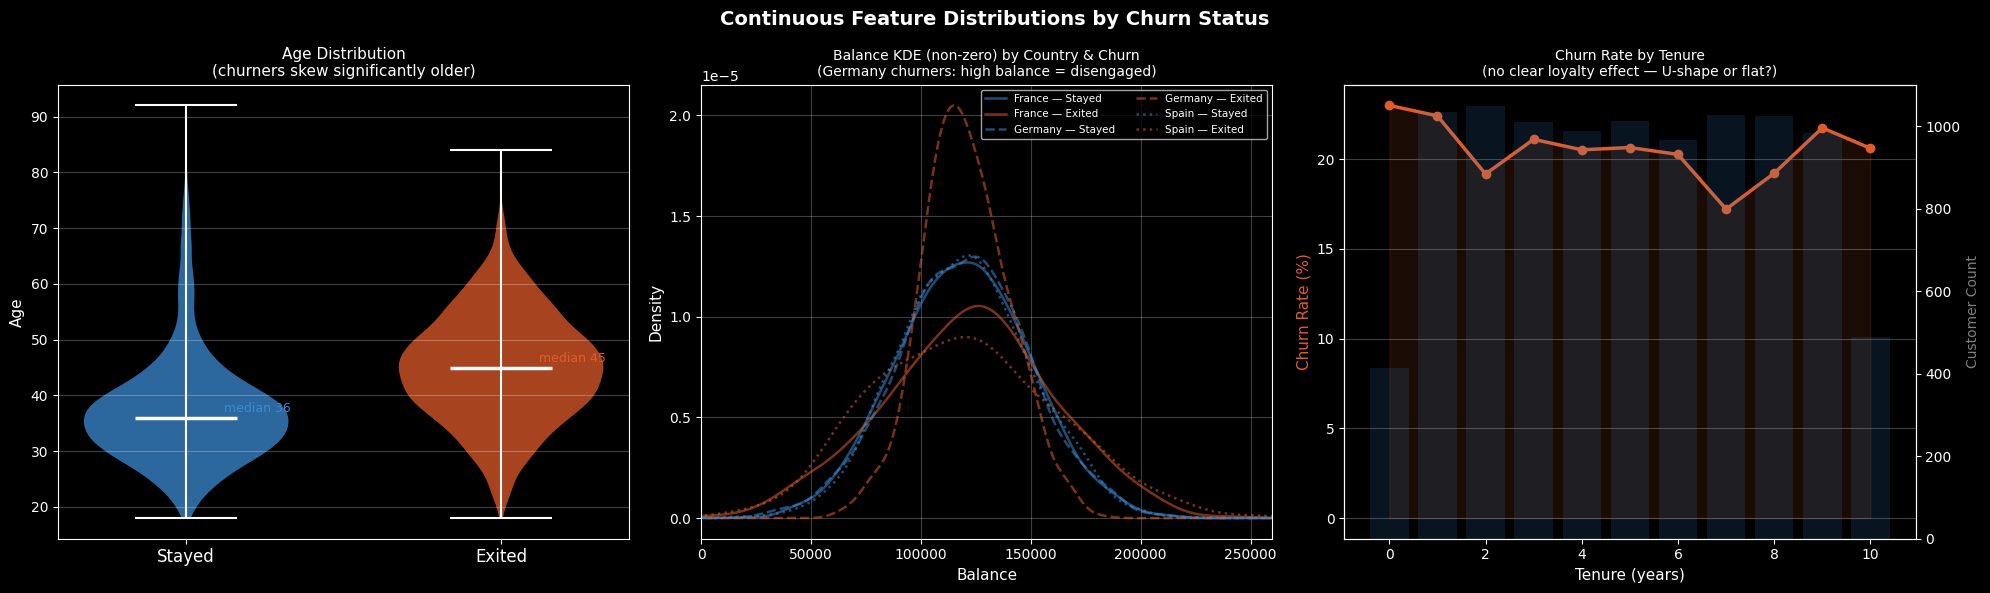

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Product Holding & Activity Analysis', fontsize=14, fontweight='bold')

#churn rate per product count
prod_churn = df.groupby('NumOfProducts')['Exited'].mean() * 100
prod_count = df.groupby('NumOfProducts').size()

ax1 = axes[0]
ax1_twin = ax1.twinx()

bars = ax1.bar(prod_churn.index, prod_churn.values,
               color=['#3B8BD4','#3B8BD4','#E05C2A','#E05C2A'],
               alpha=0.85, width=0.6, zorder=3)
ax1_twin.bar(prod_count.index, prod_count.values,
             color='white', alpha=0.08, width=0.6)

for bar, val in zip(bars, prod_churn.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
             f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')

ax1.set_xlabel('Number of Products', fontsize=11)
ax1.set_ylabel('Churn Rate (%)', fontsize=11)
ax1_twin.set_ylabel('Customer Count', fontsize=10, alpha=0.6)
ax1.set_title('Churn Rate by Number of Products\n(counterintuitive: 3–4 products = extreme risk)', fontsize=11)
ax1.grid(axis='y', alpha=0.25, zorder=0)
ax1.set_xticks([1, 2, 3, 4])

#customer count labels
for x, cnt in zip(prod_count.index, prod_count.values):
    ax1_twin.text(x, cnt/2, f'n={cnt:,}', ha='center', va='center',
                  fontsize=9, color='white', alpha=0.5)

#churn heatmap
pivot = df.pivot_table(values='Exited', index='IsActiveMember',
                       columns='NumOfProducts', aggfunc='mean') * 100
pivot.index = ['Passive', 'Active']

sns.heatmap(pivot, ax=axes[1], annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=1.5, linecolor='#1a1a1a',
            annot_kws={'size': 13, 'weight': 'bold'})
axes[1].set_title('Churn Rate % — Activity × Products\n(highest risk: passive + 3–4 products)', fontsize=11)
axes[1].set_xlabel('Number of Products', fontsize=11)
axes[1].set_ylabel('Member Status', fontsize=11)
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Demographic & Satisfaction Deep Dive', fontsize=14, fontweight='bold')

# geography,gender churn heatmap
geo_gender = df.pivot_table(values='Exited', index='Gender',
                             columns='Geography', aggfunc='mean') * 100

sns.heatmap(geo_gender, ax=axes[0], annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=2, linecolor='#1a1a1a',
            annot_kws={'size': 14, 'weight': 'bold'},
            vmin=10, vmax=45)
axes[0].set_title('Churn Rate % by Geography & Gender\n(German women: highest risk subgroup)', fontsize=10)
axes[0].set_xlabel(''); axes[0].set_ylabel('')
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)

#satisfaction score distribution
stayed  = df[df['Exited'] == 0]['Satisfaction Score']
exited  = df[df['Exited'] == 1]['Satisfaction Score']

parts = axes[1].violinplot([stayed, exited], positions=[0, 1],
                            showmedians=True, showextrema=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(['#3B8BD4', '#E05C2A'][i])
    pc.set_alpha(0.75)
parts['cmedians'].set_color('white'); parts['cmedians'].set_linewidth(2)
parts['cmins'].set_color('white');    parts['cmaxes'].set_color('white')
parts['cbars'].set_color('white')

axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Stayed', 'Exited'], fontsize=12)
axes[1].set_ylabel('Satisfaction Score (1–5)', fontsize=11)
axes[1].set_title('Satisfaction Score Distribution\n(surprisingly similar — score ≠ loyalty signal)', fontsize=10)
axes[1].grid(axis='y', alpha=0.25)

axes[1].annotate(f'median: {stayed.median():.1f}',
                 xy=(0, stayed.median()), xytext=(-0.35, stayed.median() + 0.08),
                 fontsize=9, color='#3B8BD4')
axes[1].annotate(f'median: {exited.median():.1f}',
                 xy=(1, exited.median()), xytext=(1.05, exited.median() + 0.08),
                 fontsize=9, color='#E05C2A')

# card type churn
card_churn = df.groupby(['Card Type', 'Exited']).size().unstack(fill_value=0)
card_churn_pct = card_churn.div(card_churn.sum(axis=1), axis=0) * 100
card_churn_pct = card_churn_pct.sort_values(1, ascending=False)

card_churn_pct.plot(kind='bar', ax=axes[2], stacked=True,
                    color=['#3B8BD4', '#E05C2A'], alpha=0.85, rot=0, width=0.55)
axes[2].set_title('Churn Rate by Card Type\n(does premium card reduce churn?)', fontsize=10)
axes[2].set_xlabel('Card Type', fontsize=11)
axes[2].set_ylabel('Customer %', fontsize=11)
axes[2].legend(['Stayed', 'Exited'], loc='upper right', fontsize=9)
axes[2].grid(axis='y', alpha=0.25)

#churn % labels on top of bars
for i, (idx, row) in enumerate(card_churn_pct.iterrows()):
    axes[2].text(i, 102, f"{row[1]:.1f}%", ha='center', fontsize=10, fontweight='bold', color='#E05C2A')

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Continuous Feature Distributions by Churn Status', fontsize=14, fontweight='bold')

colors = {0: '#3B8BD4', 1: '#E05C2A'}
labels = {0: 'Stayed', 1: 'Exited'}

# age — split violin
parts = axes[0].violinplot(
    [df[df['Exited']==0]['Age'], df[df['Exited']==1]['Age']],
    positions=[0, 1], showmedians=True, showextrema=True, widths=0.65
)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(['#3B8BD4','#E05C2A'][i]); pc.set_alpha(0.75)
parts['cmedians'].set_color('white'); parts['cmedians'].set_linewidth(2.5)
parts['cmins'].set_color('white');    parts['cmaxes'].set_color('white')
parts['cbars'].set_color('white')
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(['Stayed', 'Exited'], fontsize=12)
axes[0].set_ylabel('Age', fontsize=11)
axes[0].set_title('Age Distribution\n(churners skew significantly older)', fontsize=11)
axes[0].grid(axis='y', alpha=0.25)
# median lines annotation
for pos, grp in [(0, 0), (1, 1)]:
    med = df[df['Exited']==grp]['Age'].median()
    axes[0].annotate(f'median {med:.0f}', xy=(pos, med),
                     xytext=(pos + 0.12, med + 1), fontsize=9,
                     color=['#3B8BD4','#E05C2A'][pos])

# balance — KDE by churn + geography
for geo, ls in zip(['France','Germany','Spain'], ['-','--',':']):
    for exited, col in [(0,'#3B8BD4'),(1,'#E05C2A')]:
        subset = df[(df['Geography']==geo) & (df['Exited']==exited)]['Balance']
        subset[subset > 0].plot.kde(ax=axes[1], color=col, linestyle=ls,
                                    alpha=0.55, linewidth=1.8,
                                    label=f'{geo} — {"Exited" if exited else "Stayed"}')

axes[1].set_title('Balance KDE (non-zero) by Country & Churn\n(Germany churners: high balance = disengaged)', fontsize=10)
axes[1].set_xlabel('Balance', fontsize=11); axes[1].set_ylabel('Density', fontsize=11)
axes[1].legend(fontsize=7.5, ncol=2); axes[1].grid(alpha=0.25)
axes[1].set_xlim(0, 260000)

# tenure churn rate line chart
tenure_churn = df.groupby('Tenure')['Exited'].mean() * 100
tenure_count = df.groupby('Tenure').size()

ax_t  = axes[2]
ax_t2 = ax_t.twinx()

ax_t.plot(tenure_churn.index, tenure_churn.values,
          color='#E05C2A', linewidth=2.5, marker='o', markersize=6, zorder=3)
ax_t.fill_between(tenure_churn.index, tenure_churn.values,
                  alpha=0.12, color='#E05C2A')
ax_t2.bar(tenure_count.index, tenure_count.values,
          color='#3B8BD4', alpha=0.15, width=0.8)

ax_t.set_xlabel('Tenure (years)', fontsize=11)
ax_t.set_ylabel('Churn Rate (%)', fontsize=11, color='#E05C2A')
ax_t2.set_ylabel('Customer Count', fontsize=10, alpha=0.5)
ax_t.set_title('Churn Rate by Tenure\n(no clear loyalty effect — U-shape or flat?)', fontsize=10)
ax_t.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

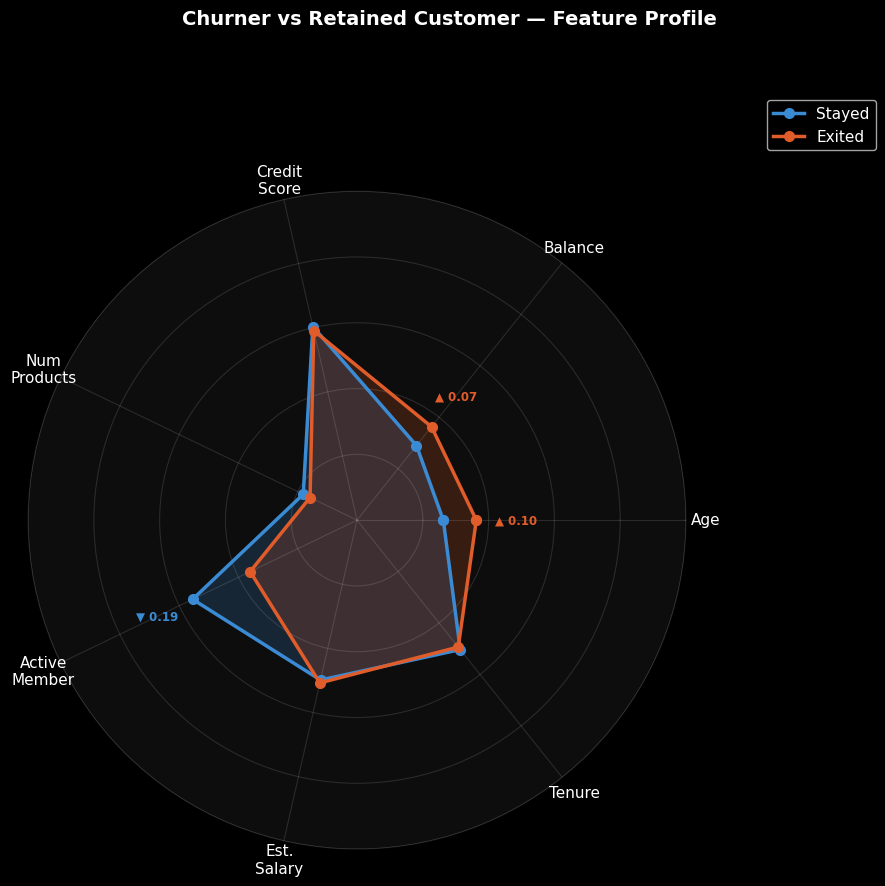

In [5]:
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

features = ['Age', 'Balance', 'CreditScore', 'NumOfProducts',
            'IsActiveMember', 'EstimatedSalary', 'Tenure']
display_names = ['Age', 'Balance', 'Credit\nScore', 'Num\nProducts',
                 'Active\nMember', 'Est.\nSalary', 'Tenure']

df_norm = df[features].copy()
for col in features:
    df_norm[col] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())

stayed_means = df_norm[df['Exited'] == 0][features].mean().values
exited_means = df_norm[df['Exited'] == 1][features].mean().values

N = len(features)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

stayed_vals = stayed_means.tolist() + [stayed_means[0]]
exited_vals = exited_means.tolist() + [exited_means[0]]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
fig.suptitle('Churner vs Retained Customer — Feature Profile',
             fontsize=14, fontweight='bold', y=1.01)

ax.set_facecolor('#0d0d0d')
ax.grid(color='white', alpha=0.12, linewidth=0.8)
for spine in ax.spines.values():
    spine.set_edgecolor('white'); spine.set_alpha(0.1)

ax.fill(angles, stayed_vals, color='#3B8BD4', alpha=0.20)
ax.fill(angles, exited_vals, color='#E05C2A', alpha=0.20)

ax.plot(angles, stayed_vals, color='#3B8BD4', linewidth=2.5, linestyle='-',
        label='Stayed',  marker='o', markersize=7)
ax.plot(angles, exited_vals, color='#E05C2A', linewidth=2.5, linestyle='-',
        label='Exited',  marker='o', markersize=7)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(display_names, fontsize=11)
ax.set_yticklabels([])
ax.set_ylim(0, 1)

for i, (feat, angle, sv, ev) in enumerate(zip(display_names, angles[:-1], stayed_means, exited_means)):
    diff = ev - sv
    if abs(diff) > 0.07:
        r = max(sv, ev) + 0.12
        color = '#E05C2A' if diff > 0 else '#3B8BD4'
        arrow = '▲' if diff > 0 else '▼'
        ax.annotate(f'{arrow} {abs(diff):.2f}',
                    xy=(angle, r), fontsize=8.5,
                    ha='center', va='center', color=color, fontweight='bold')

ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.15), fontsize=11)
plt.tight_layout()
plt.show()

###Key insight
> * Churners are older, hold more products (but still leave)
and are significantly less active the IsActiveMember gap is the most consistent signal.

In [ ]:
df.corr(numeric_only=True)

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
RowNumber,1.000000,0.004202,0.005840,0.000783,-0.006495,-0.009067,0.007246,0.000599,0.012044,-0.005988,-0.016140,-0.016957,0.009289,0.002360
CustomerId,0.004202,1.000000,0.005308,0.009497,-0.014883,-0.012419,0.016972,-0.014025,0.001665,0.015271,-0.006203,-0.007293,-0.000865,-0.013076
CreditScore,0.005840,0.005308,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.026771,-0.027048,-0.012599,0.000077
Age,0.000783,0.009497,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285296,0.283530,-0.000876,0.002222
Tenure,-0.006495,-0.014883,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.013656,-0.013047,0.008663,-0.010196
Balance,-0.009067,-0.012419,0.006268,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118577,0.119124,-0.002588,0.014608
NumOfProducts,0.007246,0.016972,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047611,-0.046357,-0.011394,-0.015330
HasCrCard,0.000599,-0.014025,-0.005458,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.006976,-0.007095,-0.000212,-0.011041
IsActiveMember,0.012044,0.001665,0.025651,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156356,-0.154741,0.010236,-0.004983
EstimatedSalary,-0.005988,0.015271,-0.001384,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012490,0.012494,-0.013747,-0.001515


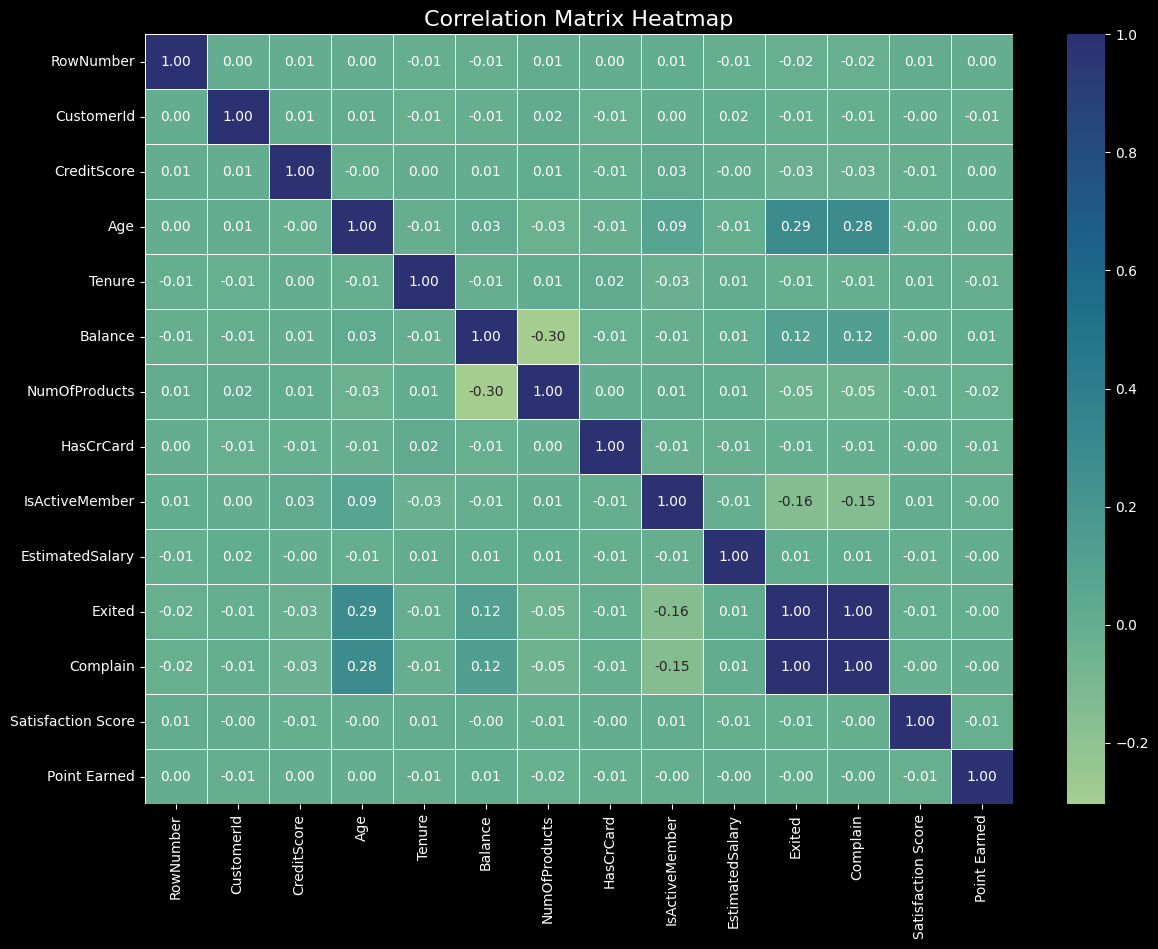

In [ ]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='crest', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix Heatmap', fontsize=16)
plt.show()

## Data Leakage Detection

* During EDA, I discovered a 0.99 correlation between Complain and Exited. Specifically, almost every churned customer had already filed a complaint.

* Including this feature would yield a 99.9% accuracy, but it’s a trap in the real world, once a customer complains, it's often too late for prevention. To build a realistic early-warning system, I removed the Complain variable to focus on deeper behavioral patterns.

In [ ]:
print('Complain × Exited:')
ct = pd.crosstab(df['Complain'], df['Exited'], margins=True)
display(ct)

print(f"\n{df[df['Complain']==1]['Exited'].mean()*100:.1f}% of those who complained left the bank")
print(f"This rate for those who did not complain is: {df[df['Complain']==0]['Exited'].mean()*100:.1f}%")

Complain × Exited:


Exited,0,1,All
Complain,,,
0,7952,4,7956
1,10,2034,2044
All,7962,2038,10000



99.5% of those who complained left the bank
This rate for those who did not complain is: 0.1%


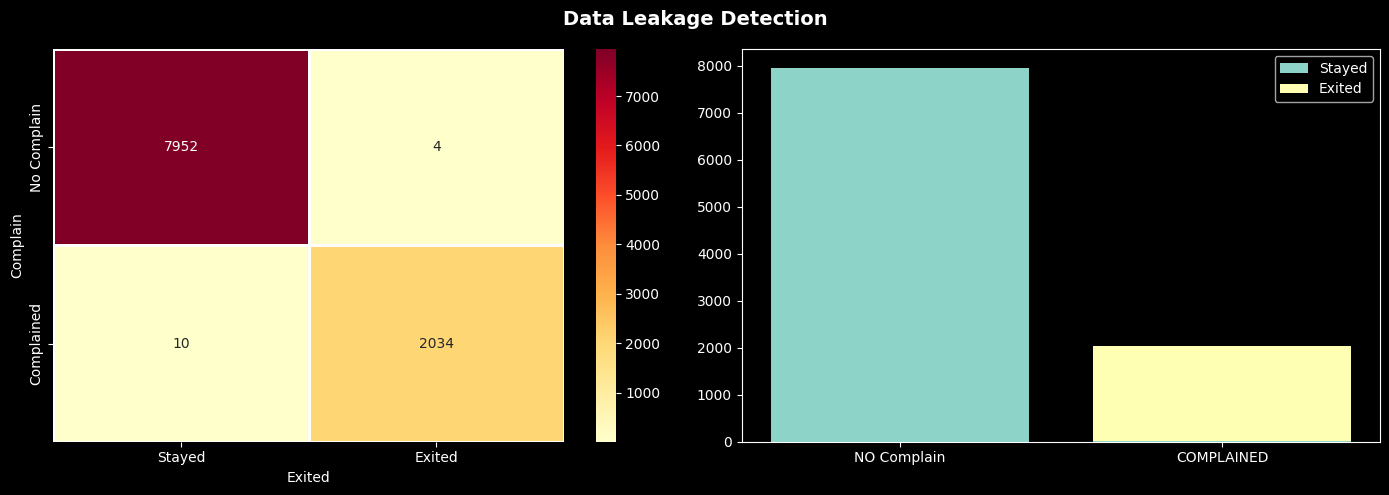

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Data Leakage Detection', fontsize=14,
             fontweight='bold')

crosstab = ct.iloc[:2, :2]
sns.heatmap(crosstab, annot=True, fmt='d', cmap='YlOrRd',
            ax=axes[0], linewidths=2,
            xticklabels=['Stayed', 'Exited'],
            yticklabels=['No Complain', 'Complained'])

categories = ['NO Complain', 'COMPLAINED']
stayed = [ct.loc[0, 0], ct.loc[1, 0]]; exited = [ct.loc[0, 1], ct.loc[1, 1]]
x = np.arange(2)
axes[1].bar(x, stayed, label='Stayed')
axes[1].bar(x, exited, bottom=stayed, label='Exited')
axes[1].set_xticks(x); axes[1].set_xticklabels(categories)
axes[1].legend()

plt.tight_layout()
plt.show()

Outlier Analysis using IQR Method:
Column 'CreditScore': 15 outliers detected.
Column 'Age': 359 outliers detected.
Column 'NumOfProducts': 60 outliers detected.
Column 'Exited': 2038 outliers detected.
Column 'Complain': 2044 outliers detected.


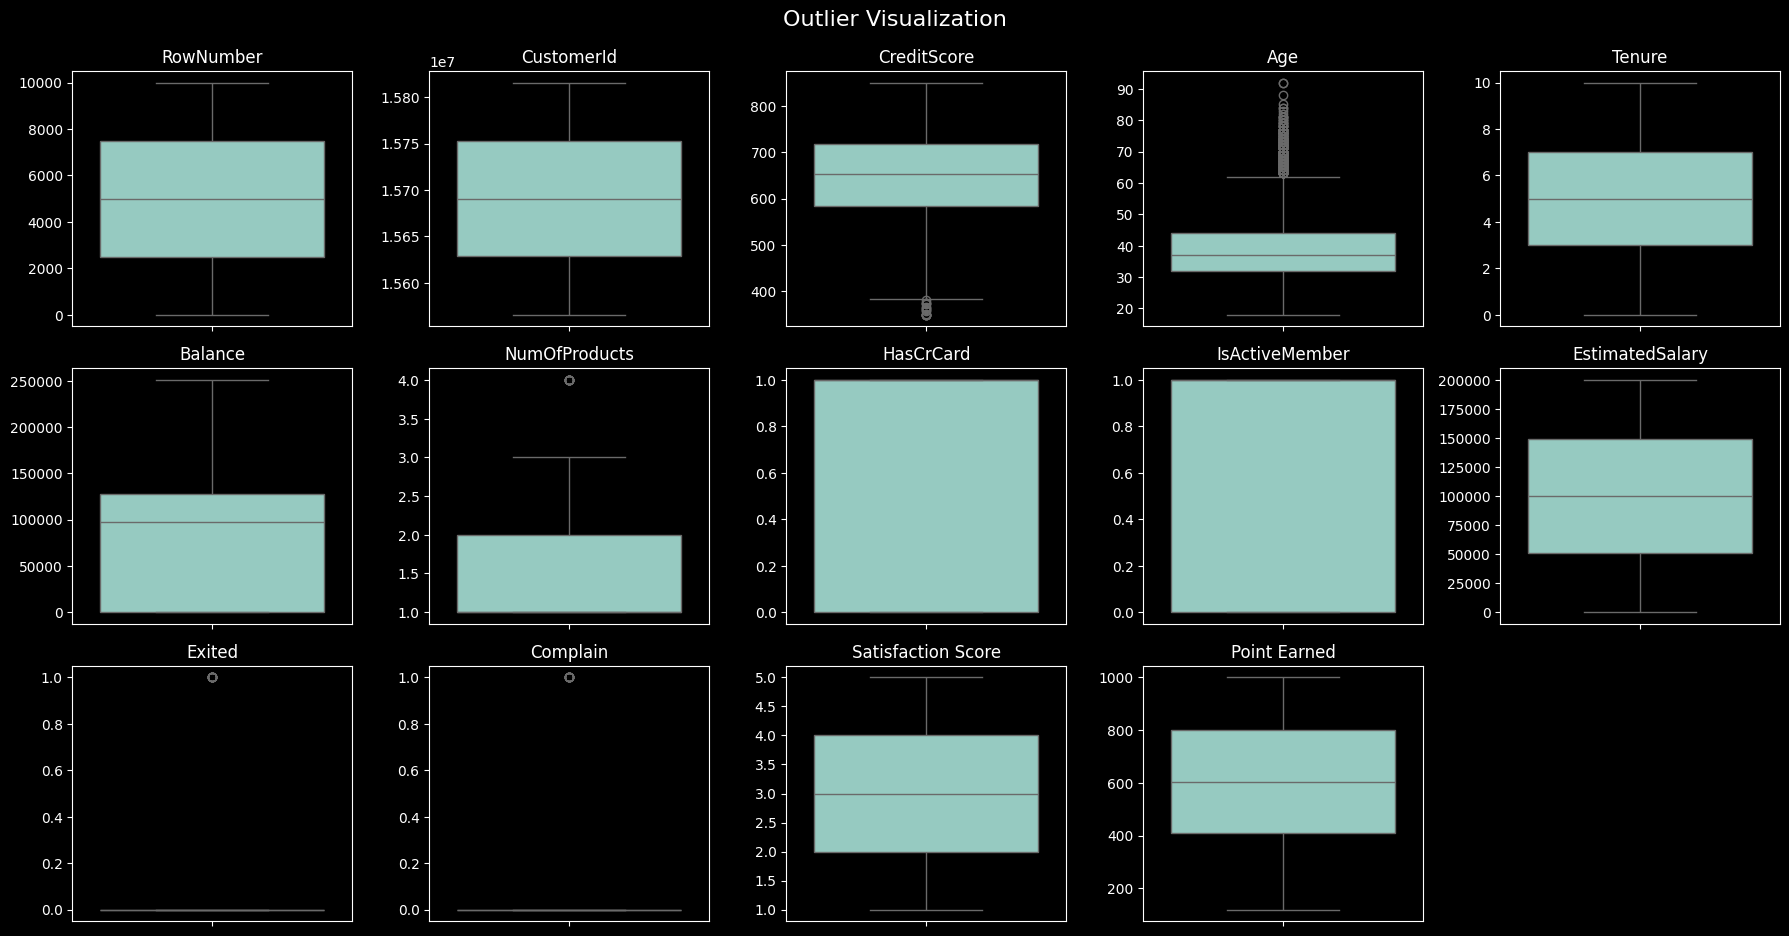

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

Q1 = df[numerical_cols].quantile(0.25)
Q3 = df[numerical_cols].quantile(0.75)
IQR = Q3 - Q1

outlier_mask = pd.DataFrame(False, index=df.index, columns=numerical_cols)

print("Outlier Analysis using IQR Method:")
for col in numerical_cols:
    lower_bound = Q1[col] - 1.5 * IQR[col]
    upper_bound = Q3[col] + 1.5 * IQR[col]
    outlier_mask[col] = (df[col] < lower_bound) | (df[col] > upper_bound)
    outliers_count = outlier_mask[col].sum()
    if outliers_count > 0:
        print(f"Column '{col}': {outliers_count} outliers detected.")

plt.figure(figsize=(18, 12))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 5, i + 1) #
    sns.boxplot(y=df[col])
    plt.title(col)
    plt.ylabel('')
plt.tight_layout()
plt.suptitle('Outlier Visualization', y=1.02, fontsize=16)
plt.show()

* I will proceed with the current dataset without aggressively removing or transforming outliers in continuous features (such as CreditScore, Age, and NumOfProducts). This is because the models I will use (XGBoost, etc.) can handle these values relatively well, and we want to preserve real-world data as much as possible.

## Feature Engineering

In [6]:
# drop unnecessary columns
df = df.drop(['RowNumber', 'CustomerId', 'Surname', 'Complain'], axis=1)

# generate new variables
df['BalanceSalaryRatio']    = df['Balance'] / (df['EstimatedSalary'] + 1)
df['AgeGroup']              = pd.cut(df['Age'], bins=[0, 30, 45, 60, 100],
                                     labels=['Young', 'Middle-aged', 'Mature', 'Senior'])
df['AgeActiveInteraction']  = df['Age'] * df['IsActiveMember']
df['ProductsPerTenure']     = df['NumOfProducts'] / (df['Tenure'] + 1)
df['HighBalance']           = (df['Balance'] > df['Balance'].median()).astype(int)

# one-hot encoding
df = pd.get_dummies(df, columns=['Geography', 'Gender', 'Card Type', 'AgeGroup'],
                    drop_first=False)

print('New features:', ['BalanceSalaryRatio', 'AgeGroup', 'AgeActiveInteraction',
                           'ProductsPerTenure', 'HighBalance'])

New features: ['BalanceSalaryRatio', 'AgeGroup', 'AgeActiveInteraction', 'ProductsPerTenure', 'HighBalance']


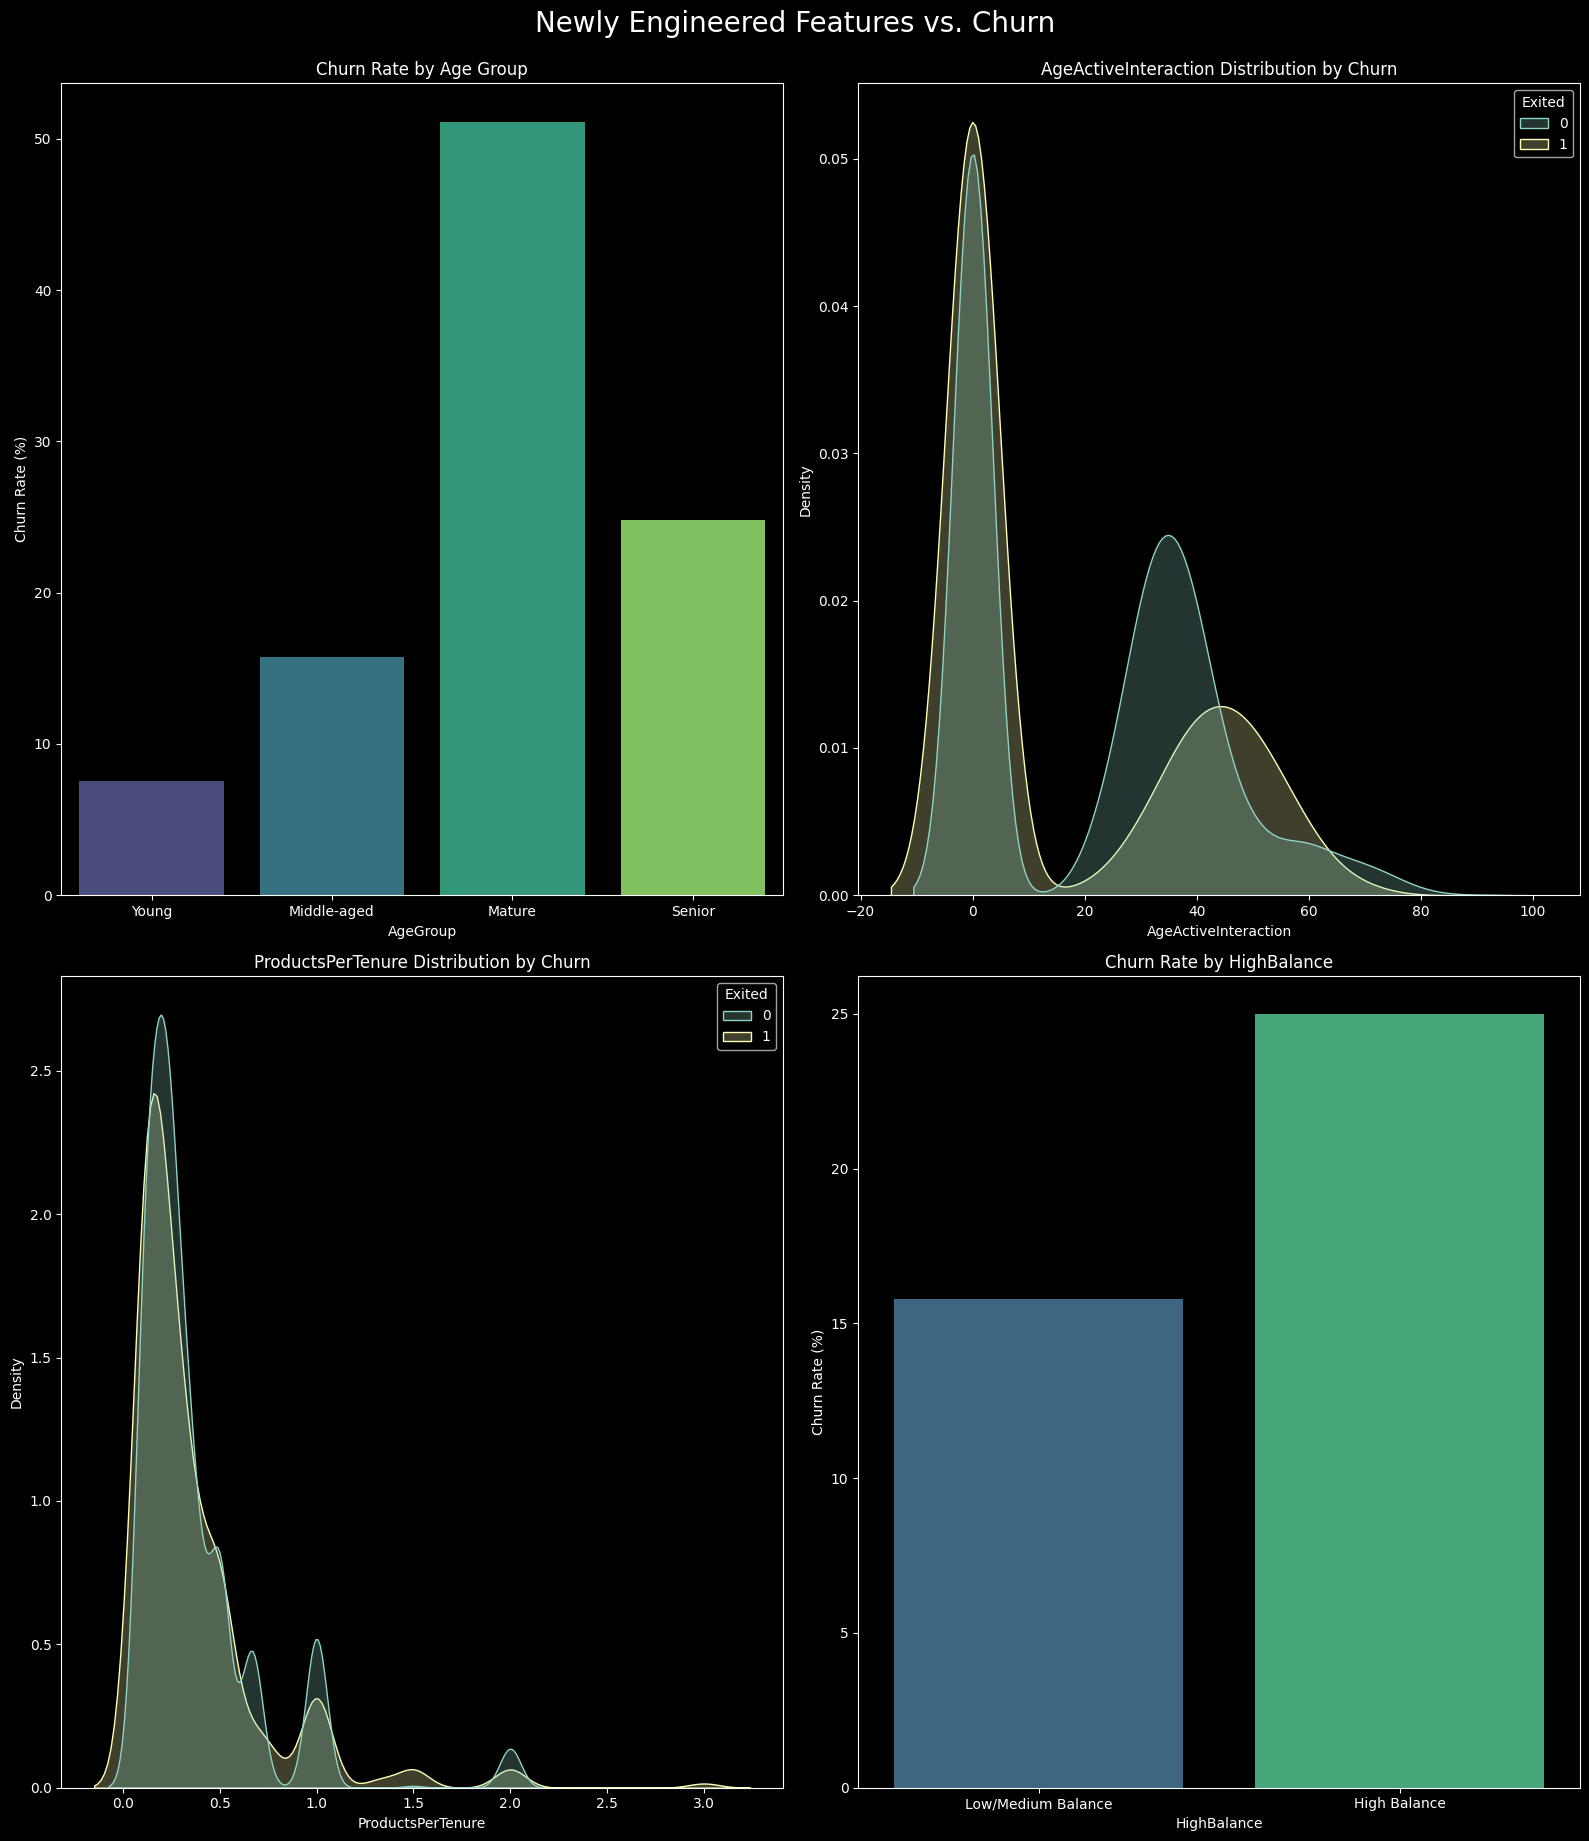

In [12]:
# Create a temporary copy of df to re-introduce 'AgeGroup' for plotting
temp_df = df.copy()
temp_df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 30, 45, 60, 100],
                             labels=['Young', 'Middle-aged', 'Mature', 'Senior'])

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 18))
axes = axes.flatten()

# churn rate by age group
churn_by_age_group = temp_df.groupby('AgeGroup')['Exited'].mean() * 100
sns.barplot(x=churn_by_age_group.index, y=churn_by_age_group.values, ax=axes[0], palette='viridis')
axes[0].set_title('Churn Rate by Age Group')
axes[0].set_ylabel('Churn Rate (%)')

# AgeActiveInteraction distribution
sns.kdeplot(data=temp_df, x='AgeActiveInteraction', hue='Exited', fill=True, ax=axes[1], common_norm=False)
axes[1].set_title('AgeActiveInteraction Distribution by Churn')

# ProductsPerTenure distribution
sns.kdeplot(data=temp_df, x='ProductsPerTenure', hue='Exited', fill=True, ax=axes[2], common_norm=False)
axes[2].set_title('ProductsPerTenure Distribution by Churn')

#churn rate by HighBalance
churn_by_high_balance = temp_df.groupby('HighBalance')['Exited'].mean() * 100
sns.barplot(x=churn_by_high_balance.index, y=churn_by_high_balance.values, ax=axes[3], palette='viridis')
axes[3].set_title('Churn Rate by HighBalance')
axes[3].set_ylabel('Churn Rate (%)')
axes[3].set_xticklabels(['Low/Medium Balance', 'High Balance'])

plt.tight_layout()
plt.suptitle('Newly Engineered Features vs. Churn', fontsize=20, y=1.02)
plt.show()

---
## SMOTE | Handling Imbalanced Data

>Our 80/20 imbalance disrupts model training.  
> * SMOTE generates **synthetic** data for the minority class.

In [13]:
X = df.drop('Exited', axis=1)
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train set size: {X_train.shape}')
print(f'Test set size : {X_test.shape}')
print(f'Train churn rate: {y_train.mean()*100:.1f}%')
print(f'Test churn rate : {y_test.mean()*100:.1f}%')

from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)

print(f'\nTrain size after balancing: {X_train_bal.shape}')
print(f'Churn rate after balancing: {y_train_bal.mean()*100:.1f}%')

Train set size: (8000, 27)
Test set size : (2000, 27)
Train churn rate: 20.4%
Test churn rate : 20.4%

Train size after balancing: (12740, 27)
Churn rate after balancing: 50.0%


---
## Model Training

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled  = scaler.transform(X_test)

###Logistic Regression

In [15]:
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_scaled, y_train_bal)
lr_pred = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, lr_pred,
                             target_names=['Stayed', 'Exited']))

              precision    recall  f1-score   support

      Stayed       0.86      0.96      0.91      1592
      Exited       0.71      0.37      0.49       408

    accuracy                           0.84      2000
   macro avg       0.78      0.67      0.70      2000
weighted avg       0.83      0.84      0.82      2000



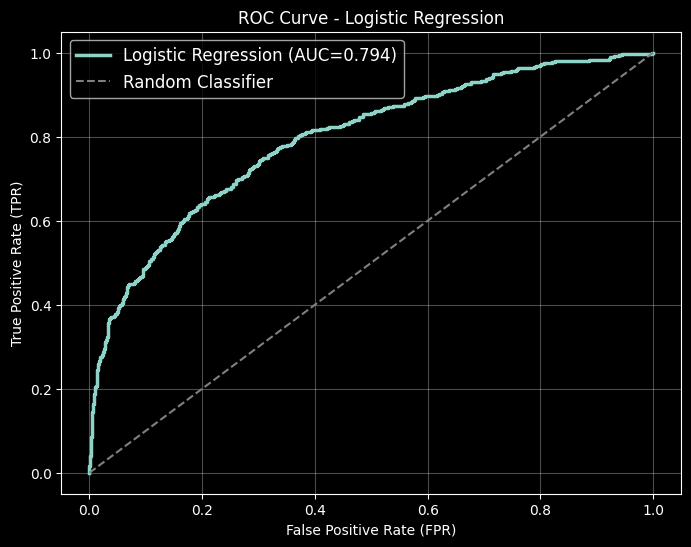

Logistic Regression ROC AUC Score: 0.794


In [16]:
fpr, tpr, _ = roc_curve(y_test, lr_prob)
auc = roc_auc_score(y_test, lr_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC={auc:.3f})', linewidth=2.5)
plt.plot([0,1],[0,1],'--', color='gray', label='Random Classifier')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve - Logistic Regression')
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.show()

print(f"Logistic Regression ROC AUC Score: {auc:.3f}")

## Random Forest

In [17]:
rf = RandomForestClassifier(n_estimators=200, max_depth=12,
                             random_state=42, n_jobs=-1)
rf.fit(X_train_bal, y_train_bal)
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, rf_pred,
                             target_names=['Stayed', 'Exited']))

              precision    recall  f1-score   support

      Stayed       0.89      0.94      0.91      1592
      Exited       0.70      0.53      0.61       408

    accuracy                           0.86      2000
   macro avg       0.80      0.74      0.76      2000
weighted avg       0.85      0.86      0.85      2000



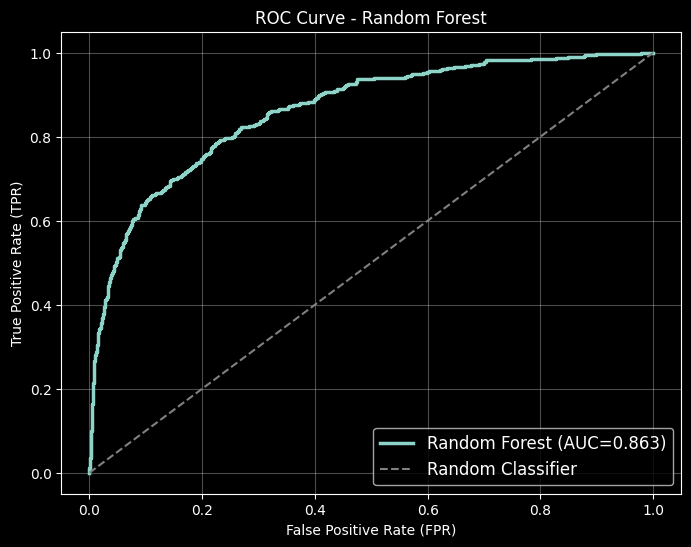

Random Forest ROC AUC Score: 0.863


In [18]:
fpr, tpr, _ = roc_curve(y_test, rf_prob)
auc = roc_auc_score(y_test, rf_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC={auc:.3f})', linewidth=2.5)
plt.plot([0,1],[0,1],'--', color='gray', label='Random Classifier')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve - Random Forest')
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.show()

print(f"Random Forest ROC AUC Score: {auc:.3f}")

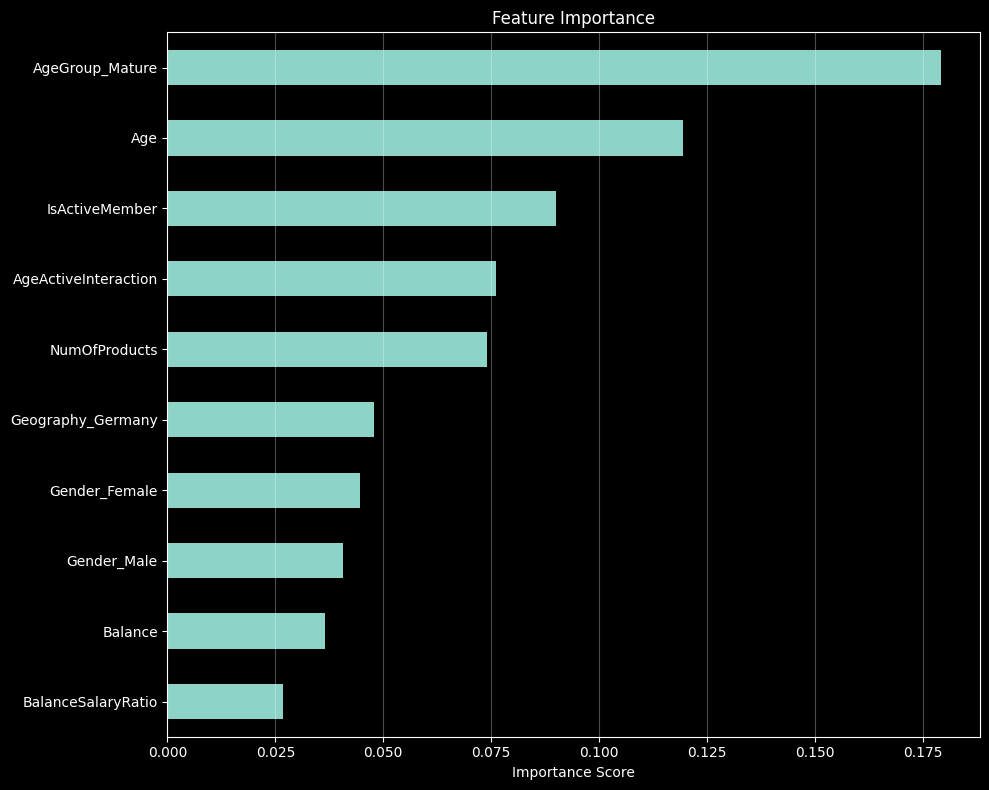

In [19]:
feat_imp_rf = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
imp_rf = feat_imp_rf.head(10)
imp_rf[::-1].plot(kind='barh', ax=ax)
ax.set_xlabel('Importance Score')
ax.set_title('Feature Importance')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## XGBoost

In [20]:
xgb_model = xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=4, random_state=42, eval_metric='logloss'
    )

xgb_model.fit(X_train_bal, y_train_bal)
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, xgb_pred, target_names=['Stayed', 'Exited']))

              precision    recall  f1-score   support

      Stayed       0.93      0.83      0.88      1592
      Exited       0.53      0.74      0.62       408

    accuracy                           0.81      2000
   macro avg       0.73      0.79      0.75      2000
weighted avg       0.85      0.81      0.82      2000



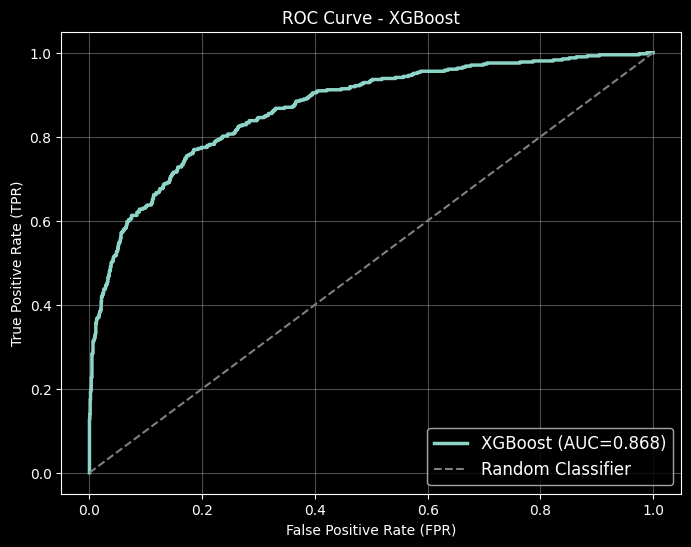

XGBoost ROC AUC Score: 0.868


In [21]:
fpr, tpr, _ = roc_curve(y_test, xgb_prob)
auc = roc_auc_score(y_test, xgb_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'XGBoost (AUC={auc:.3f})', linewidth=2.5)
plt.plot([0,1],[0,1],'--', color='gray', label='Random Classifier')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve - XGBoost')
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.show()

print(f"XGBoost ROC AUC Score: {auc:.3f}")

## LightGBM

In [22]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    force_col_wise=True
)

lgb_model.fit(X_train_bal, y_train_bal)
lgb_pred = lgb_model.predict(X_test)
lgb_prob = lgb_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, lgb_pred, target_names=['Stayed', 'Exited']))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 6370, number of negative: 6370
[LightGBM] [Info] Total Bins 1735
[LightGBM] [Info] Number of data points in the train set: 12740, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
              precision    recall  f1-score   support

      Stayed       0.89      0.95      0.92      1592
      Exited       0.74      0.54      0.62       408

    accuracy                           0.87      2000
   macro avg       0.81      0.74      0.77      2000
weighted avg       0.86      0.87      0.86      2000



# Key Performance Metrics
 * `Accuracy` metric is **misleading** in imbalanced data!  
 * If the model predicts 'Stay' for everyone, accuracy is 80% but it's useless.  

#### **Key metrics:**
> - **Recall:** How many of the leaving customers did we catch?  
> - **F1-Score:** Balance of Precision and Recall  
> - **ROC-AUC:** The model's overall distinguishing power

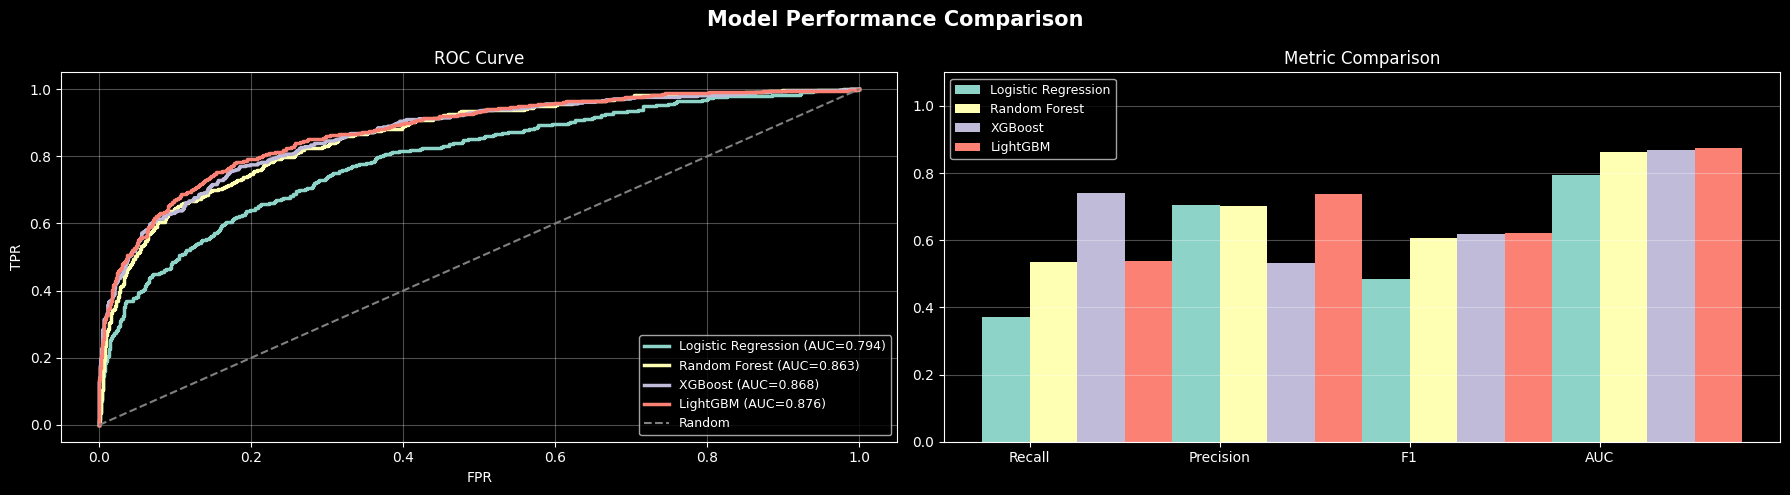


Summary Table:


,Recall,Precision,F1,AUC
Model,,,,
XGBoost,0.740,0.532,0.619,0.868
LightGBM,0.537,0.737,0.621,0.876
Random Forest,0.534,0.703,0.607,0.863
Logistic Regression,0.370,0.706,0.486,0.794


In [23]:
results = {
    'Logistic Regression': {'pred': lr_pred, 'prob': lr_prob},
    'Random Forest':       {'pred': rf_pred, 'prob': rf_prob},
    'XGBoost':             {'pred': xgb_pred, 'prob': xgb_prob},
    'LightGBM':            {'pred': lgb_pred, 'prob': lgb_prob}
}

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')

# ROC Curves
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['prob'])
    auc = roc_auc_score(y_test, res['prob'])
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})',
                 linewidth=2.5)
axes[0].plot([0,1],[0,1],'--', color='gray', label='Random')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curve')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# Metric Comparison
metrics_data = []
for name, res in results.items():
    metrics_data.append({
        'Model': name,
        'Recall': recall_score(y_test, res['pred']),
        'Precision': precision_score(y_test, res['pred']),
        'F1': f1_score(y_test, res['pred']),
        'AUC': roc_auc_score(y_test, res['prob']),
    })

mdf = pd.DataFrame(metrics_data).set_index('Model')
x = np.arange(len(mdf.columns))
width = 0.25
for i, (model, row) in enumerate(mdf.iterrows()):
    axes[1].bar(x + i*width, row.values, width, label=model)
axes[1].set_xticks(x + width/2); axes[1].set_xticklabels(mdf.columns)
axes[1].set_ylim(0, 1.1); axes[1].set_title('Metric Comparison')
axes[1].legend(fontsize=9); axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print('\nSummary Table:')
mdf.round(3).sort_values('Recall', ascending=False)

---
##SHAP

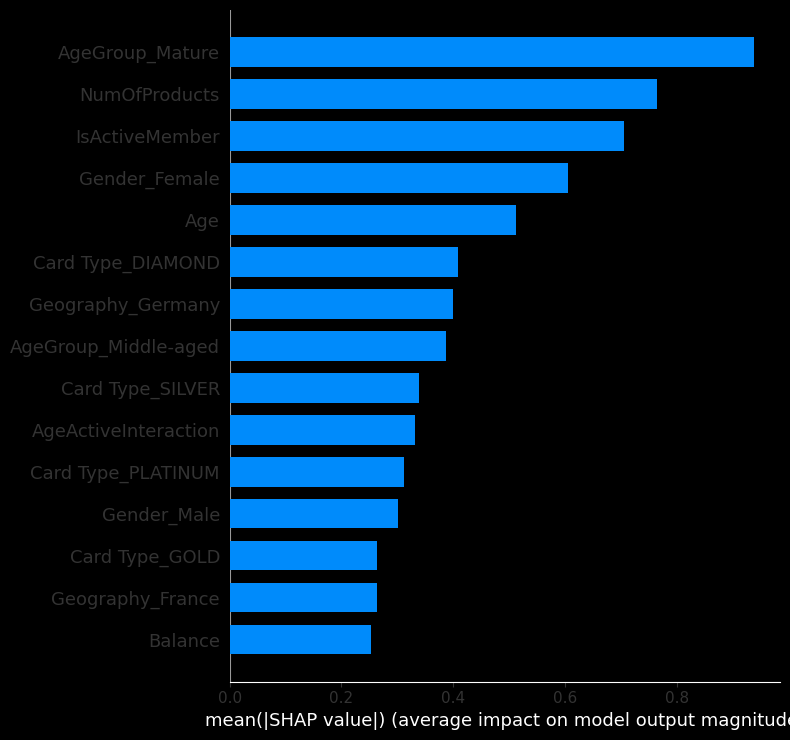

In [24]:
import shap
explainer = shap.TreeExplainer(xgb_model)
X_sample = X_test.iloc[:500]
shap_values = explainer.shap_values(X_sample)

if isinstance(shap_values, list):
    sv_plot = shap_values[1]
else:
    sv_plot = shap_values

shap.summary_plot(sv_plot, X_sample, plot_type='bar', max_display=15, show=False)
plt.show()

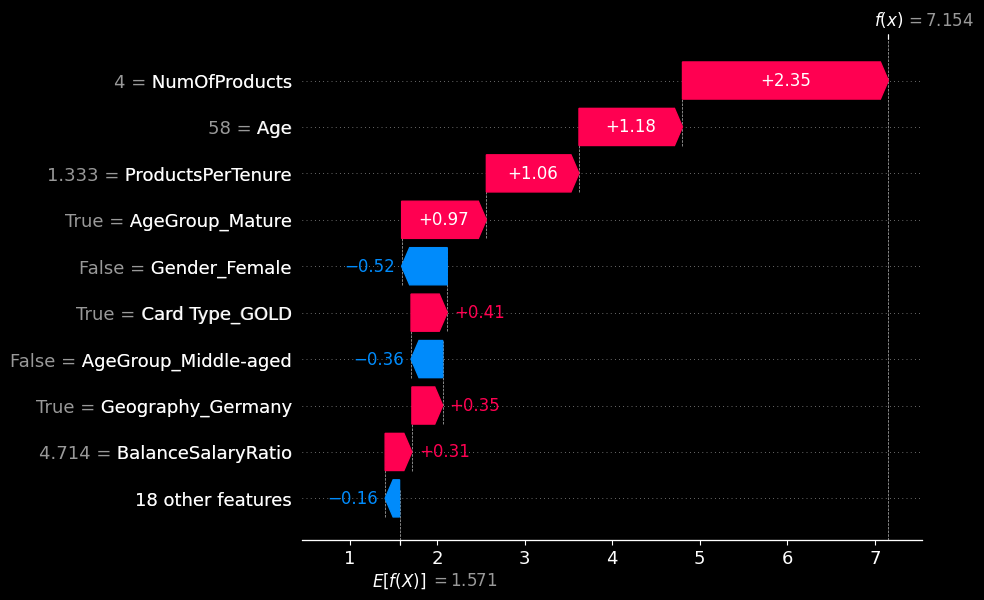

In [25]:
#waterfall plot

high_risk_idx = xgb_prob.argmax()
expected_val = explainer.expected_value
if isinstance(expected_val, (list, np.ndarray)) and len(expected_val) > 1:
    expected_val = expected_val[1]


shap.plots.waterfall(shap.Explanation(
    values=explainer.shap_values(X_test.iloc[[high_risk_idx]])[0], # Sadece o satırın SHAP değerleri
    base_values=expected_val,
    data=X_test.iloc[high_risk_idx],
    feature_names=X_test.columns.tolist()
), show=False)

plt.show()


In [30]:
import optuna
from optuna.samplers import TPESampler
import xgboost as xgb

import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)


from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, recall_score
from imblearn.pipeline import Pipeline as ImbPipeline

#maximize recall when precision is greater than or equal to 0.40
#this prevents extremely low precision, ensuring the model isn't completely nonsensical
def recall_with_precision_constraint(y_true, y_pred):
    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred)
    if p < 0.40:      # minimum precision
        return 0.0
    return r

constrained_recall = make_scorer(recall_with_precision_constraint)

def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 600),
        'max_depth':        trial.suggest_int('max_depth', 3, 10),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma':            trial.suggest_float('gamma', 0.0, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'scale_pos_weight': trial.suggest_int('scale_pos_weight', 1, 8),
        'random_state': 42,
        'verbosity': 0
    }

    # incorporate SMOTE into the CV folds
    pipe = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('model', xgb.XGBClassifier(**params))
    ])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


    scores = cross_val_score(
        pipe, X_train, y_train,
        cv=cv,
        scoring=constrained_recall,
        n_jobs=-1
    )
    return scores.mean()

study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42),
    study_name='xgb_recall_focused'
)

study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"best recall (CV): {study.best_value:.4f}")
print(f"\nbest params:")
for k, v in study.best_params.items():
    print(f"   {k}: {v}")

  0%|          | 0/50 [00:00<?, ?it/s]

best recall (CV): 0.8325

best params:
   n_estimators: 304
   max_depth: 3
   learning_rate: 0.06344151774765573
   subsample: 0.8533792103244117
   colsample_bytree: 0.9176565191510966
   min_child_weight: 10
   gamma: 0.9870116040013686
   reg_alpha: 2.6765194709714314e-06
   reg_lambda: 0.029142598670865338
   scale_pos_weight: 6


In [31]:
best_params = study.best_params.copy()
best_params.update({'random_state': 42, 'verbosity': 0})

final_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', xgb.XGBClassifier(**best_params))
])

final_pipe.fit(X_train, y_train)

tuned_prob = final_pipe.predict_proba(X_test)[:, 1]
tuned_pred = (tuned_prob >= 0.5).astype(int)

#tuned model
print(classification_report(y_test, tuned_pred, target_names=['Stayed', 'Exited']))

              precision    recall  f1-score   support

      Stayed       0.95      0.67      0.79      1592
      Exited       0.41      0.87      0.55       408

    accuracy                           0.71      2000
   macro avg       0.68      0.77      0.67      2000
weighted avg       0.84      0.71      0.74      2000



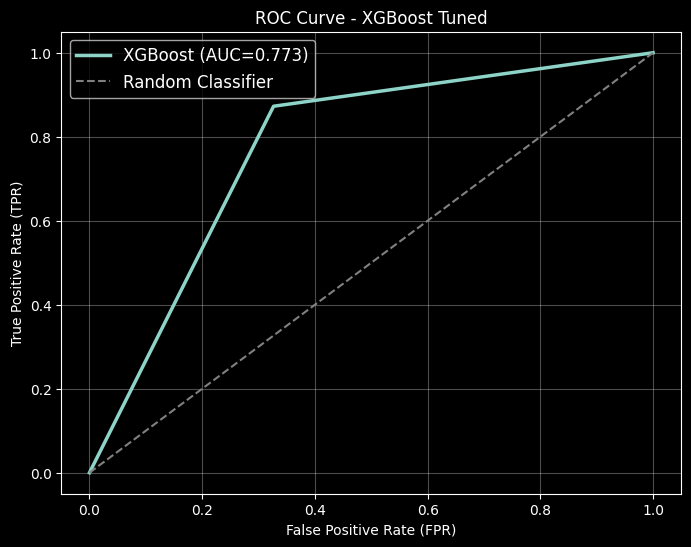

XGBoost Tuned ROC AUC Score: 0.773


In [42]:
fpr, tpr, _ = roc_curve(y_test, tuned_pred)
auc = roc_auc_score(y_test, tuned_pred)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'XGBoost (AUC={auc:.3f})', linewidth=2.5)
plt.plot([0,1],[0,1],'--', color='gray', label='Random Classifier')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve - XGBoost Tuned')
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.show()

print(f"XGBoost Tuned ROC AUC Score: {auc:.3f}")

In [32]:
thresholds = np.arange(0.05, 0.80, 0.01)

records = []
for t in thresholds:
    preds = (tuned_prob >= t).astype(int)
    records.append({
        'threshold': t,
        'precision': precision_score(y_test, preds, zero_division=0),
        'recall':    recall_score(y_test, preds),
        'f1':        f1_score(y_test, preds),
    })

tdf = pd.DataFrame(records)

# Recall >= 0.80
recall_80 = tdf[tdf['recall'] >= 0.80].sort_values('precision', ascending=False)
best_threshold_row = recall_80.iloc[0] if not recall_80.empty else tdf.loc[tdf['f1'].idxmax()]
BEST_T = best_threshold_row['threshold']

tuned_pred_opt = (tuned_prob >= BEST_T).astype(int)

print(f"Optimal threshold: {BEST_T:.2f}")
print(f"Recall:    {recall_score(y_test, tuned_pred_opt):.4f}")
print(f"Precision: {precision_score(y_test, tuned_pred_opt):.4f}")
print(f"F1:        {f1_score(y_test, tuned_pred_opt):.4f}")

Optimal threshold: 0.59
Recall:    0.8088
Precision: 0.4748
F1:        0.5984


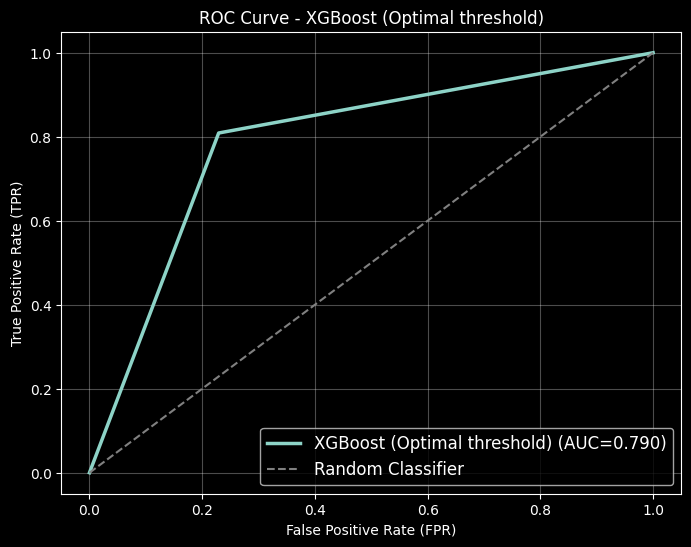

XGBoost (Optimal threshold) ROC AUC Score: 0.790


In [43]:
fpr, tpr, _ = roc_curve(y_test, tuned_pred_opt)
auc = roc_auc_score(y_test, tuned_pred_opt)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'XGBoost (Optimal threshold) (AUC={auc:.3f})', linewidth=2.5)
plt.plot([0,1],[0,1],'--', color='gray', label='Random Classifier')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve - XGBoost (Optimal threshold)')
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.show()

print(f"XGBoost (Optimal threshold) ROC AUC Score: {auc:.3f}")

#Threshold Curve

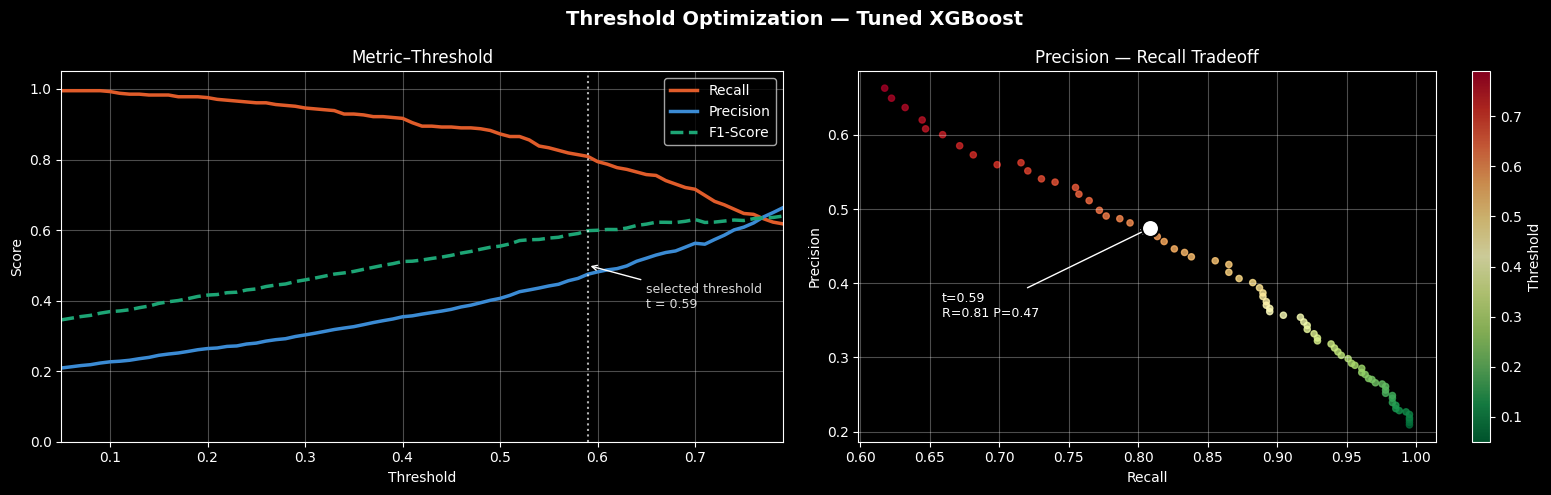

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Threshold Optimization — Tuned XGBoost', fontsize=14, fontweight='bold')

# Recall / Precision / F1 curves
axes[0].plot(tdf['threshold'], tdf['recall'],    label='Recall',    linewidth=2.5, color='#E05C2A')
axes[0].plot(tdf['threshold'], tdf['precision'], label='Precision', linewidth=2.5, color='#3B8BD4')
axes[0].plot(tdf['threshold'], tdf['f1'],        label='F1-Score',  linewidth=2.5, color='#1DA575', linestyle='--')

axes[0].axvline(x=BEST_T, color='white', linestyle=':', linewidth=1.5, alpha=0.7)
axes[0].annotate(f'selected threshold\nt = {BEST_T:.2f}',
                 xy=(BEST_T, 0.5), xytext=(BEST_T + 0.06, 0.38),
                 fontsize=9, color='white', alpha=0.85,
                 arrowprops=dict(arrowstyle='->', color='white', lw=1))

axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('Score')
axes[0].set_title('Metric–Threshold')
axes[0].legend(fontsize=10); axes[0].grid(alpha=0.3)
axes[0].set_xlim(0.05, 0.79); axes[0].set_ylim(0, 1.05)

sc = axes[1].scatter(tdf['recall'], tdf['precision'],
                     c=tdf['threshold'], cmap='RdYlGn_r',
                     s=20, alpha=0.8)
plt.colorbar(sc, ax=axes[1], label='Threshold')

best_row = tdf.loc[(tdf['threshold'] - BEST_T).abs().idxmin()]
axes[1].scatter(best_row['recall'], best_row['precision'],
                s=150, color='white', zorder=5, edgecolors='black', linewidth=1.5)
axes[1].annotate(f"t={BEST_T:.2f}\nR={best_row['recall']:.2f} P={best_row['precision']:.2f}",
                 xy=(best_row['recall'], best_row['precision']),
                 xytext=(best_row['recall'] - 0.15, best_row['precision'] - 0.12),
                 fontsize=9, color='white',
                 arrowprops=dict(arrowstyle='->', color='white', lw=1))

axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision — Recall Tradeoff')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

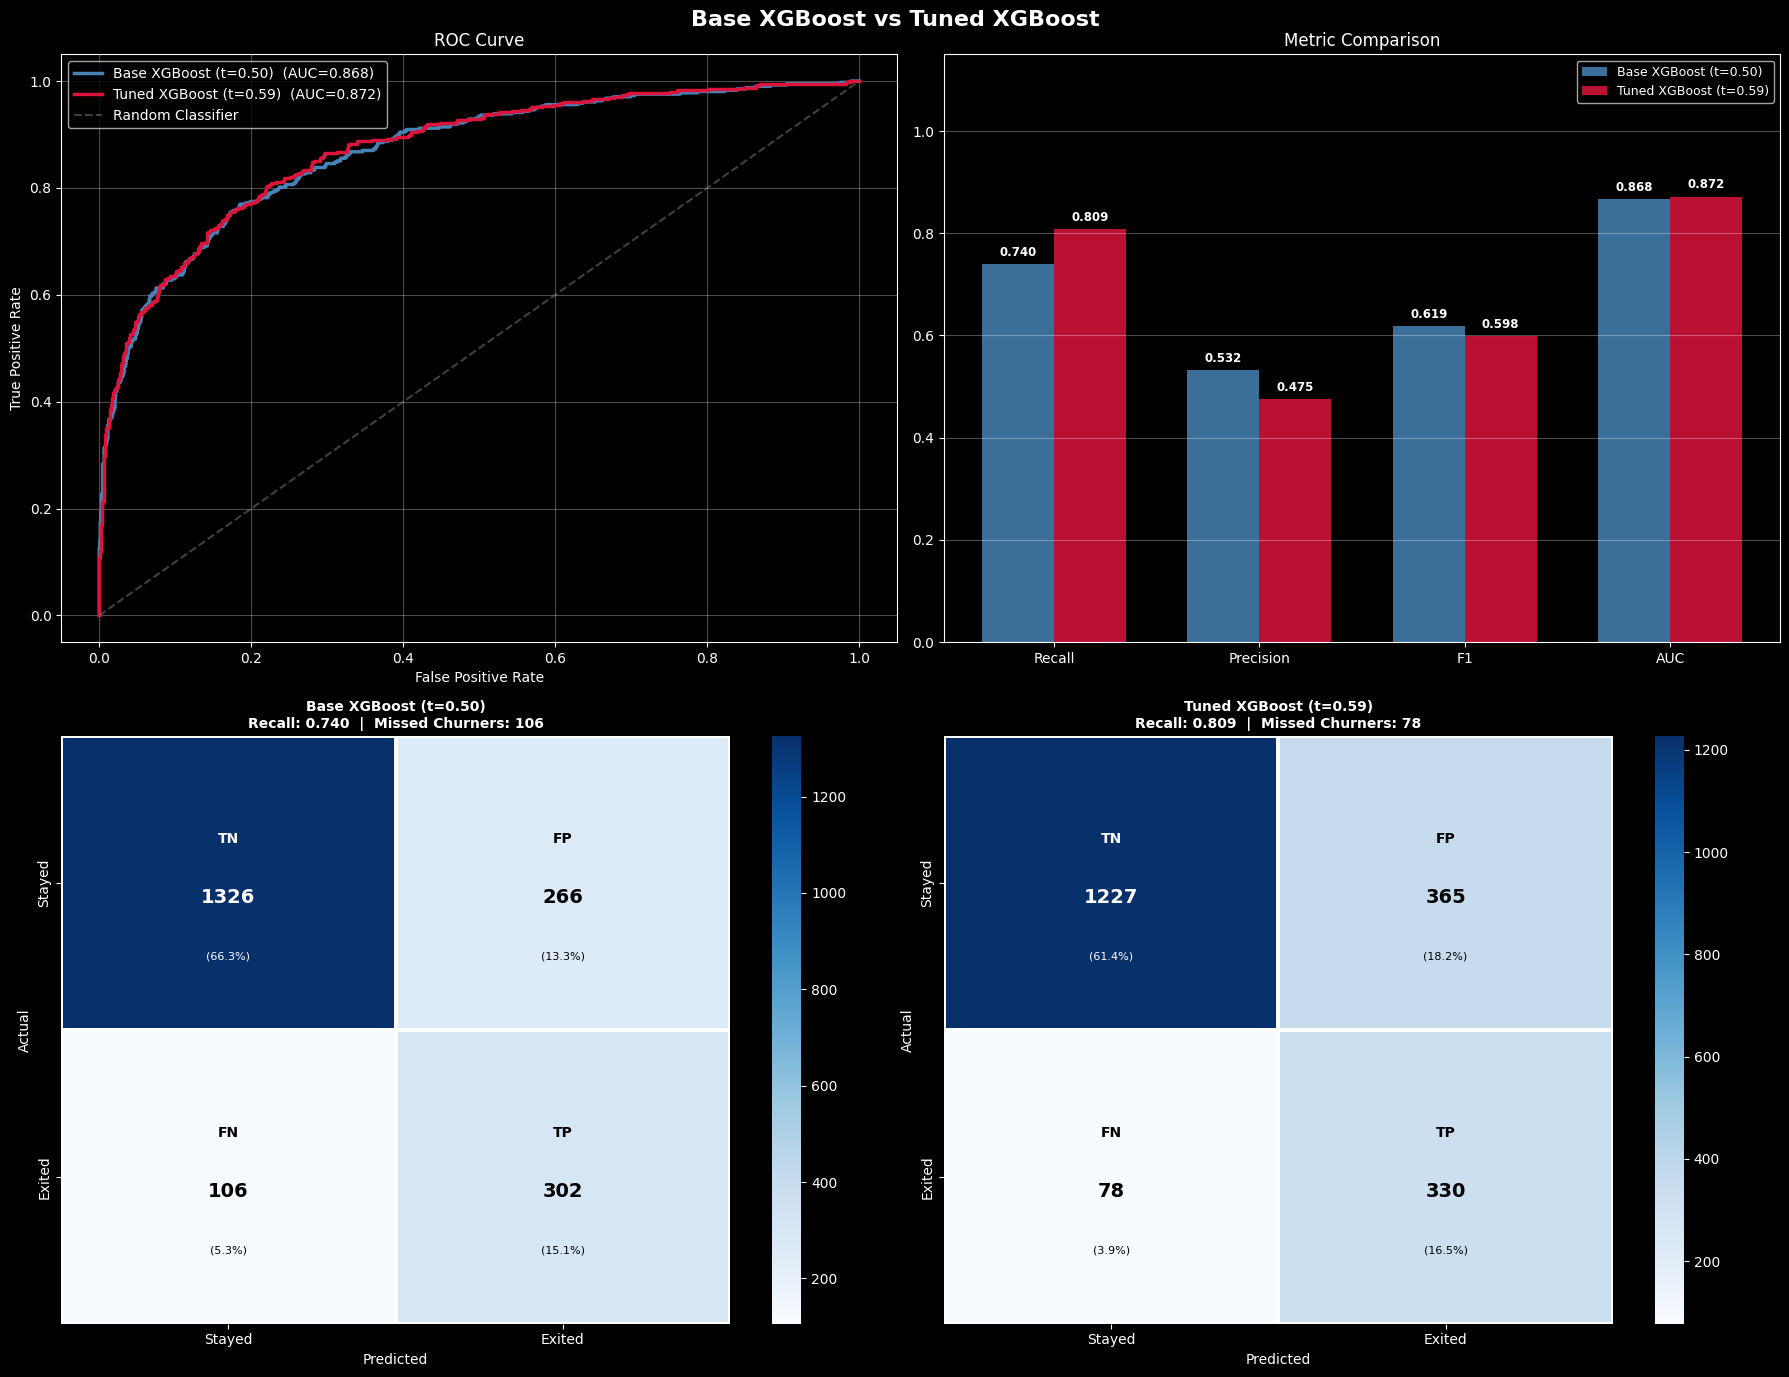

In [40]:
compare_data = {
    'Base XGBoost (t=0.50)':          (xgb_pred,       xgb_prob),
    f'Tuned XGBoost (t={BEST_T:.2f})': (tuned_pred_opt, tuned_prob),
}

rows = []
for name, (pred, prob) in compare_data.items():
    rows.append({
        'Model':     name,
        'Recall':    recall_score(y_test, pred),
        'Precision': precision_score(y_test, pred, zero_division=0),
        'F1':        f1_score(y_test, pred),
        'AUC':       roc_auc_score(y_test, prob),
    })

compare_df = pd.DataFrame(rows).set_index('Model')

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Base XGBoost vs Tuned XGBoost',
             fontsize=16, fontweight='bold')

clr = ['steelblue', 'crimson']

#roc curve
ax = axes[0, 0]
for i, (name, (pred, prob)) in enumerate(compare_data.items()):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, label=f'{name}  (AUC={auc:.3f})',
            color=clr[i], linewidth=2.5)
ax.plot([0,1],[0,1], '--', color='gray', alpha=0.5, label='Random Classifier')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend(fontsize=10); ax.grid(alpha=0.3)

#metrics
ax2 = axes[0, 1]
metric_cols = ['Recall', 'Precision', 'F1', 'AUC']
x = np.arange(len(metric_cols))
width = 0.35
for i, (name, row) in enumerate(compare_df.iterrows()):
    bars = ax2.bar(x + i*width, row[metric_cols], width,
                   label=name, color=clr[i], alpha=0.85)
    for bar, val in zip(bars, row[metric_cols]):
        ax2.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom',
                 fontsize=8.5, fontweight='bold')
ax2.set_xticks(x + width/2); ax2.set_xticklabels(metric_cols)
ax2.set_ylim(0, 1.15)
ax2.set_title('Metric Comparison')
ax2.legend(fontsize=9); ax2.grid(axis='y', alpha=0.3)

#confusion matrix
for idx, (name, (pred, prob)) in enumerate(compare_data.items()):
    ax3 = axes[1, idx]
    cm = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()

    sns.heatmap(cm, annot=False, cmap='Blues', ax=ax3,
                linewidths=1.5, linecolor='white',
                xticklabels=['Stayed', 'Exited'],
                yticklabels=['Stayed', 'Exited'])

    total = len(y_test)
    labels = [['TN','FP'],['FN','TP']]
    for i in range(2):
        for j in range(2):
            val = cm[i, j]
            pct = val / total * 100
            txt_color = 'white' if val > cm.max()/2 else 'black'
            ax3.text(j+0.5, i+0.35, labels[i][j],
                     ha='center', va='center',
                     fontsize=10, fontweight='bold', color=txt_color)
            ax3.text(j+0.5, i+0.55, str(val),
                     ha='center', va='center',
                     fontsize=14, fontweight='bold', color=txt_color)
            ax3.text(j+0.5, i+0.75, f'({pct:.1f}%)',
                     ha='center', va='center',
                     fontsize=8, color=txt_color)

    ax3.set_title(
        f'{name}\nRecall: {tp/(tp+fn):.3f}  |  Missed Churners: {fn}',
        fontsize=10, fontweight='bold')
    ax3.set_ylabel('Actual'); ax3.set_xlabel('Predicted')

plt.tight_layout()
plt.show()